Steps: [(0, 0), (3, 0), (3, 5), (0, 5), (3, 2), (0, 2), (2, 0), (2, 5), (3, 4)]


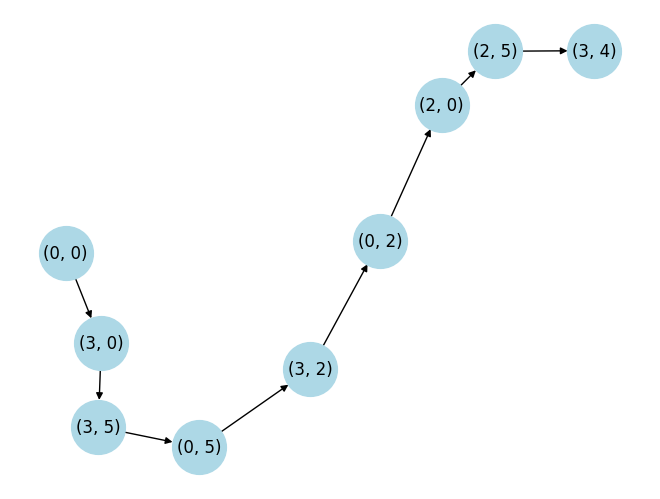

In [1]:
# Water Jug Problem

import networkx as nx
import matplotlib.pyplot as plt

def solve_jugs(c1, c2, target):
    visited = set()
    path = []

    def dfs(j1, j2):
        if (j1, j2) in visited: return False
        visited.add((j1, j2))
        path.append((j1, j2))
        if j1 == target or j2 == target: return True

        moves = [(c1, j2), (j1, c2), (0, j2), (j1, 0),
                 (j1 - min(j1, c2 - j2), j2 + min(j1, c2 - j2)),
                 (j1 + min(j2, c1 - j1), j2 - min(j2, c1 - j1))]

        for m in moves:
            if dfs(*m): return True
        path.pop()
        return False

    if dfs(0, 0):
        print("Steps:", path)
        G = nx.DiGraph()
        G.add_edges_from(zip(path, path[1:]))
        nx.draw(G, with_labels=True, node_color='lightblue', node_size=1500)
        plt.show()
    else:
        print("No solution")

solve_jugs(3, 5, 4)

Path: [(3, 3, 1), (2, 2, 0), (3, 2, 1), (3, 0, 0), (3, 1, 1), (1, 1, 0), (2, 2, 1), (0, 2, 0), (0, 3, 1), (0, 1, 0), (0, 2, 1), (0, 0, 0)]


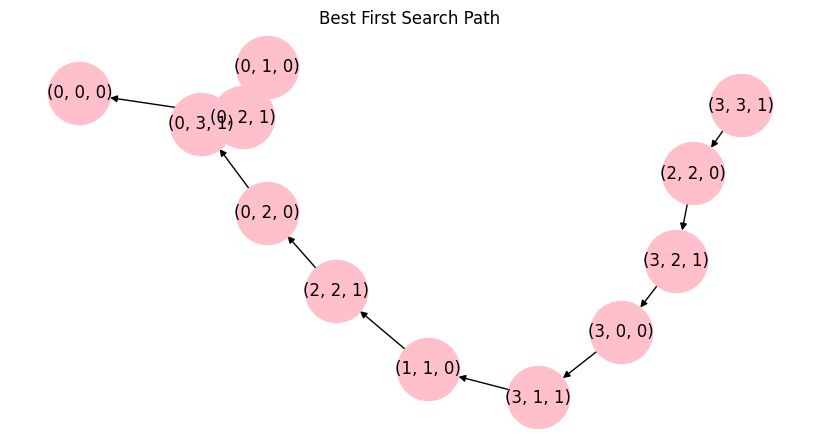

In [2]:
#2.Implement and Demonstrate Best First Search Algorithm on Missionaries-Cannibals Problems using Python

import heapq
import networkx as nx
import matplotlib.pyplot as plt

def is_valid(m, c):
    if m < 0 or m > 3 or c < 0 or c > 3: return False
    if (m > 0 and m < c) or (3-m > 0 and 3-m < 3-c): return False
    return True

def get_next(state):
    m, c, b = state
    moves = [(1,0), (2,0), (0,1), (0,2), (1,1)]
    next_states = []
    for dm, dc in moves:
        nm, nc = (m-dm, c-dc) if b == 1 else (m+dm, c+dc)
        if is_valid(nm, nc):
            next_states.append((nm, nc, 1-b))
    return next_states

def h(state):
    return state[0] + state[1] # Simple heuristic: people remaining on left

def bfs_search():
    start, goal = (3, 3, 1), (0, 0, 0)
    pq = [(h(start), start, [start])]
    visited = set()
    
    while pq:
        (f, curr, path) = heapq.heappop(pq)
        if curr in visited: continue
        if curr == goal: return path
        visited.add(curr)
        for nxt in get_next(curr):
            heapq.heappush(pq, (h(nxt), nxt, path + [nxt]))

path = bfs_search()
print("Path:", path)

# Visualization
G = nx.DiGraph()
for i in range(len(path)-1):
    G.add_edge(str(path[i]), str(path[i+1]))

plt.figure(figsize=(8,4))
nx.draw(G, with_labels=True, node_color='pink', node_size=2000)
plt.title("Best First Search Path")
plt.show()

Shortest Path: ['A', 'E', 'D', 'G']


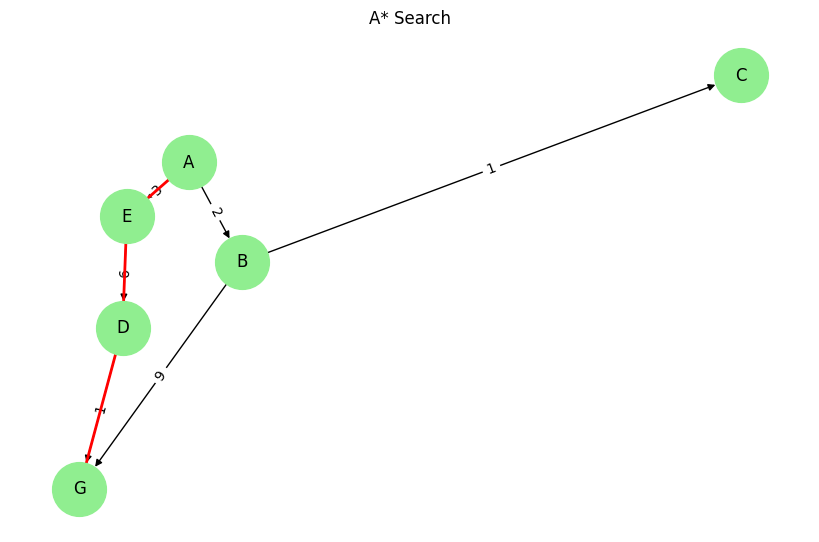

In [3]:
# A* Search

import networkx as nx
import matplotlib.pyplot as plt

# 1. Graph and Heuristic Data
graph = {
    'A': [('B', 2), ('E', 3)],
    'B': [('C', 1), ('G', 9)],
    'C': [],
    'E': [('D', 6)],
    'D': [('G', 1)],
    'G': []
}

h = {'A': 11, 'B': 6, 'C': 99, 'D': 1, 'E': 7, 'G': 0}

def a_star(start, stop):
    open_set = {start}
    closed_set = set()
    g = {start: 0}
    parents = {start: start}

    while open_set:
        # Find node with lowest f(n) = g(n) + h(n)
        n = min(open_set, key=lambda v: g[v] + h[v])

        if n == stop:
            path = []
            while parents[n] != n:
                path.append(n)
                n = parents[n]
            path.append(start)
            return path[::-1]

        for (m, weight) in graph.get(n, []):
            if m not in open_set and m not in closed_set:
                open_set.add(m)
                parents[m] = n
                g[m] = g[n] + weight
            elif g[m] > g[n] + weight:
                g[m] = g[n] + weight
                parents[m] = n
                if m in closed_set:
                    closed_set.remove(m)
                    open_set.add(m)

        open_set.remove(n)
        closed_set.add(n)
    return None

# 2. Execution and Visualization
path = a_star('A', 'G')
print(f"Shortest Path: {path}")

G = nx.DiGraph()
for u, neighbors in graph.items():
    for v, w in neighbors:
        G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G)
plt.figure(figsize=(8, 5))
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1500)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

if path:
    path_edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)

plt.title("A* Search")
plt.show()

In [4]:
# N-Queens Problem

N = 8


# CHECK IF POSITION IS SAFE
def is_safe(board, row, col):

    # Check upper column
    for i in range(row):
        if board[i][col] == 1:
            return False

    # Check left diagonal
    i = row
    j = col

    while i >= 0 and j >= 0:
        if board[i][j] == 1:
            return False
        i -= 1
        j -= 1

    # Check right diagonal
    i = row
    j = col

    while i >= 0 and j < N:
        if board[i][j] == 1:
            return False
        i -= 1
        j += 1

    return True


# SOLVE USING BACKTRACKING
def solve(board, row):

    # All queens placed
    if row == N:
        return True

    for col in range(N):

        if is_safe(board, row, col):

            board[row][col] = 1

            # Recur for next row
            if solve(board, row + 1):
                return True

            # Backtrack
            board[row][col] = 0

    return False


# PRINT BOARD
def display(board):

    for row in board:
        print(row)


# MAIN
board = [[0]*N for i in range(N)]

if solve(board, 0):
    display(board)
else:
    print("No Solution")

[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]


Path: [0, 1, 3, 2, 0]
Total Cost: 80


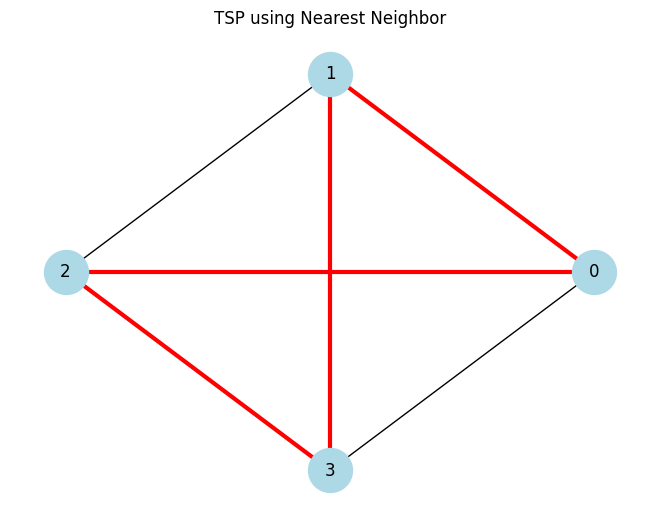

In [5]:
# Travelling Salesman Problem
# Using Nearest Neighbor Heuristic

import networkx as nx
import matplotlib.pyplot as plt


# TSP FUNCTION
def tsp(cost):
    n = len(cost)
    visited = [False] * n
    path = [0]
    visited[0] = True
    current = 0
    total = 0


    # Find nearest city
    for i in range(n - 1):
        nearest = -1
        min_cost = 999
        
        for j in range(n):

            if not visited[j] and cost[current][j] < min_cost:

                min_cost = cost[current][j]
                nearest = j

        visited[nearest] = True

        path.append(nearest)

        total += min_cost

        current = nearest


    # Return to start city
    total += cost[current][0]

    path.append(0)

    return total, path


# GRAPH VISUALIZATION
def draw_graph(cost, path):

    G = nx.Graph()

    n = len(cost)

    # Add edges
    for i in range(n):
        for j in range(i + 1, n):

            G.add_edge(i, j, weight=cost[i][j])


    pos = nx.circular_layout(G)

    # Draw graph
    nx.draw(G, pos,
            with_labels=True,
            node_color='lightblue',
            node_size=1000)

    # Highlight TSP path
    edges = list(zip(path, path[1:]))

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edges,
        edge_color='red',
        width=3
    )

    plt.title("TSP using Nearest Neighbor")
    plt.show()


# COST MATRIX
cost = [

    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]

]


# MAIN
total, path = tsp(cost)

print("Path:", path)

print("Total Cost:", total)

draw_graph(cost, path)


Updated Cost:

D : {'J': 1}
C : {'H AND I': 2, 'G': 4}
B : {'E OR F': 8}
A : {'C AND D': 5, 'B': 9}

**************************************************

Shortest Path:

A --> (C AND D)

Visualizing Graph...



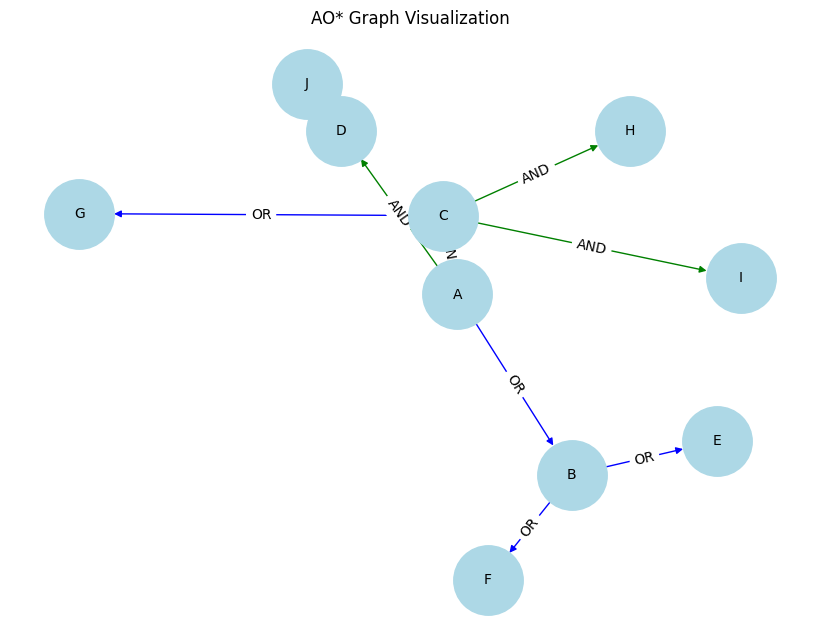

In [12]:
# AO* Algorithm (Simple Version with Visualization)

import networkx as nx
import matplotlib.pyplot as plt


# Function to calculate cost
def find_cost(H, condition, weight=1):

    cost = {}

    # AND condition
    if "AND" in condition:
        and_nodes = condition["AND"]

        path = " AND ".join(and_nodes)

        total = 0
        for node in and_nodes:
            total += H[node] + weight

        cost[path] = total

    # OR condition
    if "OR" in condition:
        or_nodes = condition["OR"]

        path = " OR ".join(or_nodes)

        min_cost = min(H[node] + weight for node in or_nodes)

        cost[path] = min_cost

    return cost


# Update heuristic values
def update_cost(H, Conditions, weight=1):

    nodes = list(Conditions.keys())
    nodes.reverse()

    updated_cost = {}

    for node in nodes:

        condition = Conditions[node]

        print(node, ":", find_cost(H, condition, weight))

        c = find_cost(H, condition, weight)

        H[node] = min(c.values())

        updated_cost[node] = c

    return updated_cost


# Find shortest path
def shortest_path(start, Updated_cost):

    path = start

    if start in Updated_cost:

        min_cost = min(Updated_cost[start].values())

        for p in Updated_cost[start]:

            if Updated_cost[start][p] == min_cost:

                next_nodes = p.split()

                # OR path
                if len(next_nodes) == 1:
                    path += " --> " + shortest_path(next_nodes[0], Updated_cost)

                # AND path
                else:
                    path += " --> (" + p + ")"

                break

    return path


# Graph Visualization
def visualize_graph(Conditions):

    G = nx.DiGraph()

    for node, condition in Conditions.items():

        if "AND" in condition:
            for n in condition["AND"]:
                G.add_edge(node, n, color="green", label="AND")

        if "OR" in condition:
            for n in condition["OR"]:
                G.add_edge(node, n, color="blue", label="OR")

    pos = nx.spring_layout(G)

    edge_colors = [G[u][v]["color"] for u, v in G.edges()]
    edge_labels = nx.get_edge_attributes(G, "label")

    plt.figure(figsize=(8, 6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        node_size=2500,
        font_size=10,
        edge_color=edge_colors,
        arrows=True
    )

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("AO* Graph Visualization")
    plt.show()


# ---------------- SAMPLE INPUT ----------------

H = {
    'A': -1,
    'B': 5,
    'C': 2,
    'D': 4,
    'E': 7,
    'F': 9,
    'G': 3,
    'H': 0,
    'I': 0,
    'J': 0
}

Conditions = {

    'A': {
        'OR': ['B'],
        'AND': ['C', 'D']
    },

    'B': {
        'OR': ['E', 'F']
    },

    'C': {
        'OR': ['G'],
        'AND': ['H', 'I']
    },

    'D': {
        'OR': ['J']
    }
}

weight = 1


# ---------------- OUTPUT ----------------

print("\nUpdated Cost:\n")

Updated_cost = update_cost(H, Conditions, weight)

print("\n" + "*" * 50)

print("\nShortest Path:\n")

print(shortest_path('A', Updated_cost))

print("\nVisualizing Graph...\n")

visualize_graph(Conditions)

In [6]:
def forward_chaining(rules, facts, goal):
    inferred_facts = set(facts)
    new_facts = True
    
    while new_facts:
        new_facts = False
        
        for rule in rules:
            condition, result = rule
            
            if all(cond in inferred_facts for cond in condition) and result not in inferred_facts:
                inferred_facts.add(result)
                new_facts = True
                
                if result == goal:
                    return True
    
    return False


def backward_chaining(rules, facts, goal):
    def ask(query):
        if query in facts:
            return True
        
        for rule in rules:
            condition, result = rule
            if result == query and all(ask(cond) for cond in condition):
                return True
        
        return False
    
    return ask(goal)


# Define the rules and facts for the animal classification problem
rules = [
    (['hair', 'live young'], 'mammal'),
    (['feathers', 'fly'], 'bird')
]


facts = ['hair', 'live young']
goal = 'mammal'




# Use forward chaining to determine if a cat is classified as a mammal
is_mammal = forward_chaining(rules, facts, goal)


if is_mammal:
    print("The cat is classified as a mammal.")
else:
    print("The cat is not classified as a mammal.")


facts = ['feathers', 'fly']
goal = 'bird'


# Use backward chaining to determine if a pigeon is classified as a bird
is_bird = backward_chaining(rules, facts, goal)


if is_bird:
    print("The pigeon is classified as a bird.")
else:
    print("The pigeon is not classified as a bird.")


The cat is classified as a mammal.
The pigeon is classified as a bird.


In [7]:
# Forward Chaining and Backward Chaining


# FORWARD CHAINING
def forward(rules, facts, goal):

    inferred = set(facts)

    changed = True

    while changed:

        changed = False

        for condition, result in rules:

            # Check if all conditions are true
            if all(c in inferred for c in condition):

                if result not in inferred:

                    inferred.add(result)

                    changed = True

    return goal in inferred


# BACKWARD CHAINING
def backward(rules, facts, goal):

    # Goal already present
    if goal in facts:
        return True

    # Search rules
    for condition, result in rules:

        if result == goal:

            # Check all conditions recursively
            if all(backward(rules, facts, c) for c in condition):

                return True

    return False


# RULES
rules = [

    (['hair', 'live young'], 'mammal'),

    (['feathers', 'fly'], 'bird')

]


# FORWARD CHAINING TEST
facts = ['hair', 'live young']

goal = 'mammal'


if forward(rules, facts, goal):

    print("Cat is Mammal")

else:

    print("Cat is not Mammal")


# BACKWARD CHAINING TEST
facts = ['feathers', 'fly']

goal = 'bird'


if backward(rules, facts, goal):

    print("Pigeon is Bird")

else:

    print("Pigeon is not Bird")

Cat is Mammal
Pigeon is Bird


In [9]:
from typing import List, Tuple, Optional
from copy import deepcopy


def is_variable(x: str) -> bool:
    return x[0].islower()


def unify(x: str, y: str) -> Optional[dict]:
    if x == y:
        return {}
    elif is_variable(x):
        return {x: y}
    elif is_variable(y):
        return {y: x}
    else:
        return None

def substitute(clause: List[str], subs: dict) -> List[str]:
    result = []
    for literal in clause:
        neg = False
        if literal.startswith('¬'):
            neg = True
            literal = literal[1:]
        pred, args = literal.split('(')
        args = args.strip(')').split(',')
        new_args = [subs.get(arg, arg) for arg in args]
        new_literal = f"{pred}({','.join(new_args)})"
        if neg:
            new_literal = '¬' + new_literal
        result.append(new_literal)
    return result

def resolve(ci: List[str], cj: List[str]) -> List[List[str]]:
    resolvents = []
    for li in ci:
        for lj in cj:
            # Check for complementary literals
            if li.startswith('¬') and not lj.startswith('¬') and li[1:].split('(')[0] == lj.split('(')[0]:
                xi = li[1:]
                xj = lj
            elif lj.startswith('¬') and not li.startswith('¬') and lj[1:].split('(')[0] == li.split('(')[0]:
                xi = li
                xj = lj[1:]
            else:
                continue
            # Parse args
            pred_i, args_i = xi.split('(')
            args_i = args_i.strip(')').split(',')
            pred_j, args_j = xj.split('(')
            args_j = args_j.strip(')').split(',')


            # Try unifying
            if len(args_i) != len(args_j):
                continue
            subs = {}
            for a, b in zip(args_i, args_j):
                res = unify(a, b)
                if res is None:
                    break
                subs.update(res)
            else:
                # Apply substitution and combine clauses
                new_ci = [l for l in ci if l != li]
                new_cj = [l for l in cj if l != lj]
                new_clause = substitute(new_ci + new_cj, subs)
                resolvents.append(new_clause)
    return resolvents


def resolution(clauses: List[List[str]]) -> bool:
    new = []
    while True:
        n = len(clauses)
        for i in range(n):
            for j in range(i + 1, n):
                resolvents = resolve(clauses[i], clauses[j])
                for r in resolvents:
                    if not r:  # empty clause
                        return True
                    if r not in new and r not in clauses:
                        new.append(r)
        if not new:
            return False
        clauses.extend(new)


# ----------------------------
# Input clauses (in CNF)


# Clause 1: ¬Human(x) ∨ Mortal(x)
# Clause 2: Human(Socrates)
# Negated query: ¬Mortal(Socrates)


kb = [
    ['¬Human(x)', 'Mortal(x)'],
    ['Human(Socrates)'],
    ['¬Mortal(Socrates)']
]


# Run resolution
if resolution(kb):
    print("Query is entailed: Socrates is Mortal")
else:
    print("Query is NOT entailed")


Query is entailed: Socrates is Mortal


In [10]:
# Resolution in Predicate Logic (Simple Version)


# KNOWLEDGE BASE
kb = [

    ['¬Human(x)', 'Mortal(x)'],

    ['Human(Socrates)'],

    ['¬Mortal(Socrates)']

]


# SIMPLE RESOLUTION FUNCTION
def resolution(kb):

    human_found = False
    mortal_found = False


    for clause in kb:

        # Check Human(Socrates)
        if 'Human(Socrates)' in clause:
            human_found = True


        # Check negated query
        if '¬Mortal(Socrates)' in clause:
            mortal_found = True


    # Apply rule
    if human_found and mortal_found:

        print("Resolved Human")

        print("Resolved Mortal")

        return True


    return False


# MAIN
if resolution(kb):

    print("Socrates is Mortal")

else:

    print("Cannot Prove")

Resolved Human
Resolved Mortal
Socrates is Mortal


In [11]:
import random

def show(b):
    print(f"{b[0]}|{b[1]}|{b[2]}\n-+-+-\n{b[3]}|{b[4]}|{b[5]}\n-+-+-\n{b[6]}|{b[7]}|{b[8]}\n")

def check_win(b, p):
    win_pos = [[0,1,2],[3,4,5],[6,7,8],[0,3,6],[1,4,7],[2,5,8],[0,4,8],[2,4,6]]
    return any(all(b[i] == p for i in pos) for pos in win_pos)

def play():
    board = [str(i+1) for i in range(9)]
    show(board)
    
    for turn in range(9):
        p = 'X' if turn % 2 == 0 else 'O'
        if p == 'X':
            move = int(input("Your move (1-9): ")) - 1
        else:
            move = random.choice([i for i, x in enumerate(board) if x not in ['X','O']])
            print(f"Computer chose {move+1}")
            
        board[move] = p
        show(board)
        
        if check_win(board, p):
            print(f"{p} Wins!")
            return
    print("It's a Tie!")

play()

1|2|3
-+-+-
4|5|6
-+-+-
7|8|9



Your move (1-9):  1


X|2|3
-+-+-
4|5|6
-+-+-
7|8|9

Computer chose 4
X|2|3
-+-+-
O|5|6
-+-+-
7|8|9



Your move (1-9):  5


X|2|3
-+-+-
O|X|6
-+-+-
7|8|9

Computer chose 6
X|2|3
-+-+-
O|X|O
-+-+-
7|8|9



Your move (1-9):  9


X|2|3
-+-+-
O|X|O
-+-+-
7|8|X

X Wins!


In [ ]:
import random

def play_game():
    choices - ["rock", "paper", "scissors"]
    print("Welcome to Rock, Paper, Scissors!")
    print("Type 'rock', 'paper', or 'scissors'. Type 'exit' to quit.")
    
    while True:
        user_choice = input("You: ").lower()
        if user_choice == 'exit':
            print("Thanks for playing!")
            break
        if user_choice not in choices:
            print("Invalid choice. Try again.")
            continue
        
        computer_choice = random.choice(choices)
        print(f"Computer: {computer_choice}")
        
        if user_choice == computer_choice:
            print("It's a tie!")
        elif (user_choice == "rock" and computer_choice == "scissors") or \
            (user_choice = "scissors" and computer_choice = "paper") or \
            (user_choice == "paper" and computer_choice == "rock"):
            print("You win!")
        else:
            print("You lose!")

# Run the game
play_game()